# basic

In [38]:
%load_ext autoreload
%autoreload all

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
import polars as pl
import numpy as np
import pickle
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import src.configs_mapped as configs
 

In [40]:
df_performance = pl.read_parquet(f"{configs.Results().path}scores.parquet").with_columns(
    final_score = pl.col("sem_cov_score") * pl.col("distance_score") * pl.col("uniqueness_entropy_score")
)
ks = np.arange(500, 12000, 1000)
for i in range(len(ks) - 1):
    min_k = ks[i]
    max_k = ks[i + 1]
    df = df_performance.filter(pl.col("k").is_between(min_k, max_k))
    best = df.sort(by = "final_score", descending=True).head(1)["method"][0]
    print(f"{min_k} -- {max_k}: {best}")

500 -- 1500: mg_inv
1500 -- 2500: mg_inv
2500 -- 3500: mg_inv
3500 -- 4500: mg_inv
4500 -- 5500: b_highest_deg_dist_1_list
5500 -- 6500: b_highest_deg_dist_1_list
6500 -- 7500: b_highest_deg_dist_1_list
7500 -- 8500: b_highest_deg_dist_1_list
8500 -- 9500: b_highest_deg_dist_1_list
9500 -- 10500: b_highest_deg_dist_1_list
10500 -- 11500: b_highest_deg_dist_1_list


In [41]:
df_performance

method,k,sem_cov_score,distance_score,uniqueness_entropy_score,conciseness_score,compression_rate,UNK_rate,exact_rate,num_candidates,final_score
str,i64,f64,f64,f64,f64,f64,f64,f64,i64,f64
"""b_highest_deg_list""",500,0.80276,0.50739,0.798519,0.273855,0.010293,0.049577,0.001712,475,0.325247
"""b_highest_deg_list""",1000,0.869245,0.538622,0.864342,0.250095,0.020087,0.032438,0.003619,927,0.40468
"""b_highest_deg_list""",1500,0.906695,0.559051,0.890573,0.235788,0.029989,0.02377,0.006176,1384,0.451422
"""b_highest_deg_list""",2000,0.924164,0.575507,0.905518,0.229296,0.039848,0.020888,0.008732,1839,0.481611
"""b_highest_deg_list""",2500,0.936367,0.588951,0.919833,0.226703,0.049881,0.018917,0.011289,2302,0.507264
…,…,…,…,…,…,…,…,…,…,…
"""b_random_k""",9500,0.538815,0.489653,0.72487,0.526672,0.199304,0.132773,0.126142,9197,0.191244
"""b_random_k""",10000,0.568221,0.507821,0.740652,0.504612,0.209296,0.115565,0.132508,9659,0.213719
"""b_random_k""",10500,0.564677,0.510299,0.751273,0.50956,0.219372,0.117299,0.139243,10124,0.216482


# correlation matrix

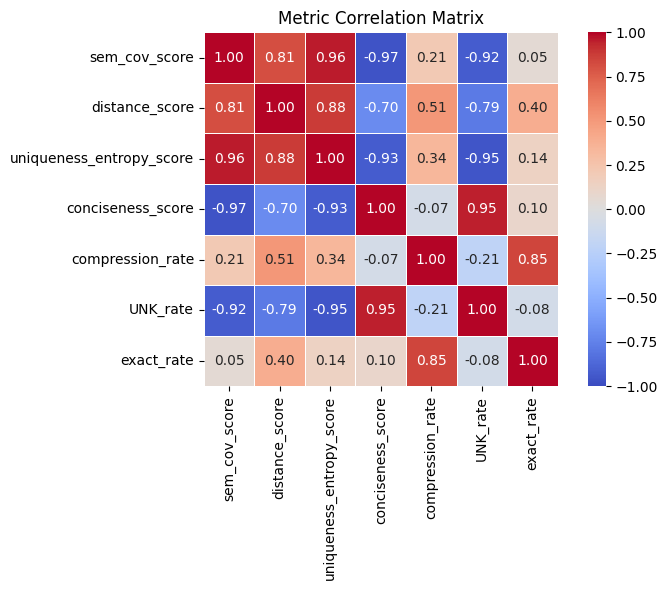

In [42]:
df_performance = pl.read_parquet(f"{configs.Results().path}scores.parquet")
metrics = [
    "sem_cov_score",
    "distance_score",
    "uniqueness_entropy_score",
    "conciseness_score",
    "compression_rate",
    "UNK_rate",
    "exact_rate",
]

corr = df_performance.select(metrics).to_pandas().corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Metric Correlation Matrix")
fig.tight_layout()
plt.show()

# plots

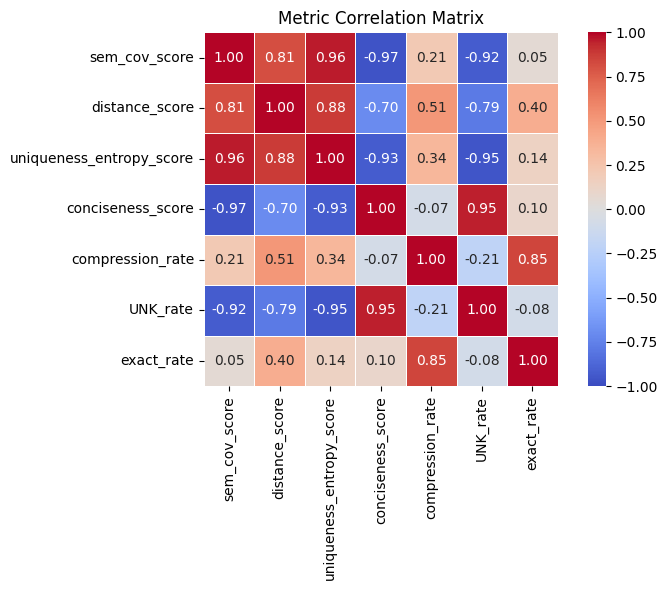

In [43]:
metrics = [
    "sem_cov_score",
    "distance_score",
    "uniqueness_entropy_score",
    "conciseness_score",
    "compression_rate",
    "UNK_rate",
    "exact_rate",
]

corr = df_performance.select(metrics).to_pandas().corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Metric Correlation Matrix")
fig.tight_layout()
plt.show()

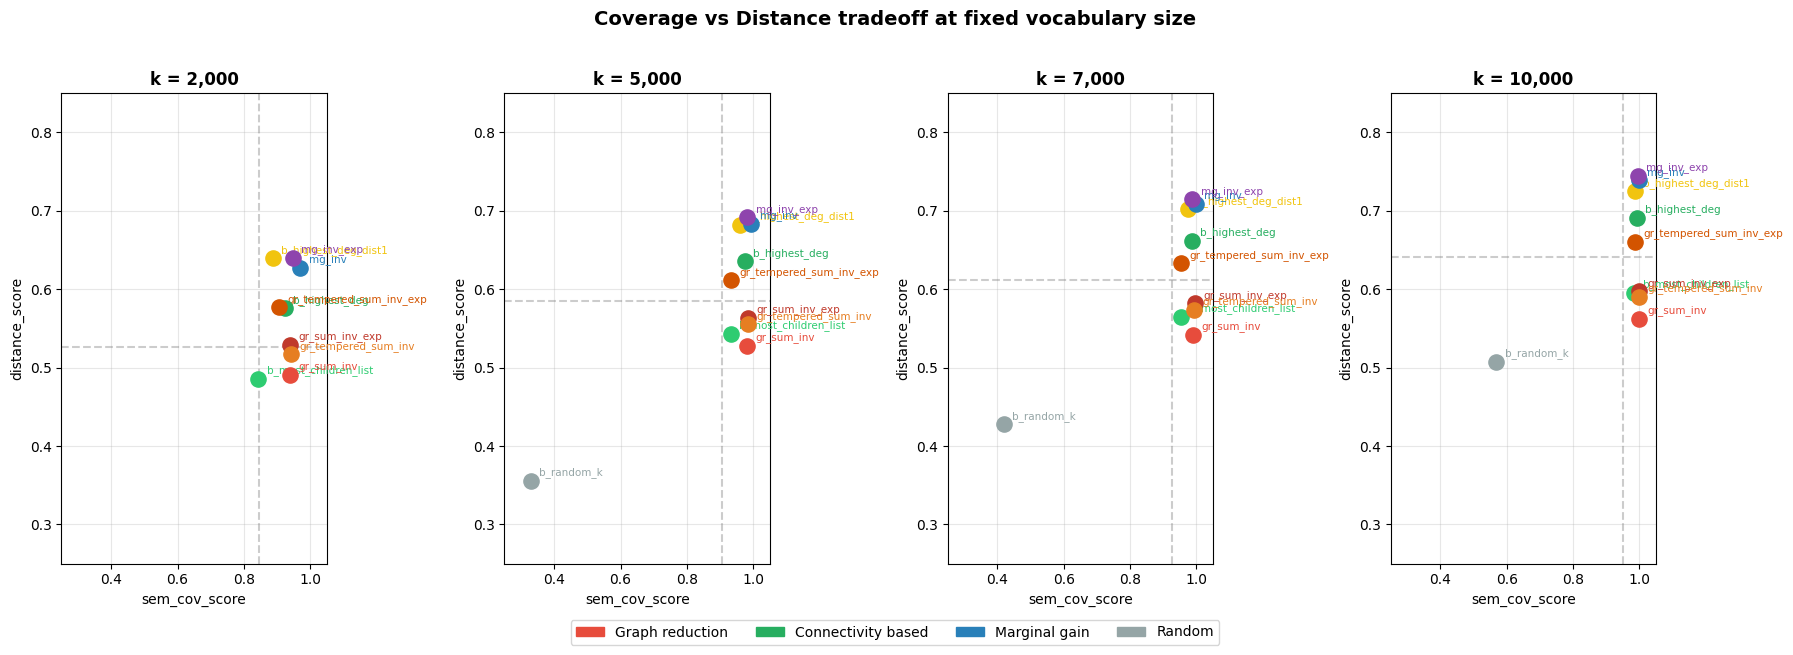

In [44]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Color mapping by method family ---
colors = {
    'gr_sum_inv': '#e74c3c',              # Graph reduction → red shades
    'gr_sum_inv_exp': '#c0392b',
    'gr_tempered_sum_inv': '#e67e22',
    'gr_tempered_sum_inv_exp': '#d35400',
    'b_highest_deg_list': '#27ae60',      # Connectivity → green shades
    'b_most_children_list': '#2ecc71',
    'b_random_k': '#95a5a6',              # Random → gray
    'b_highest_deg_dist_1_list': '#f1c40f',
    'mg_inv': '#2980b9',                  # Marginal gain → blue/purple
    'mg_inv_exp': '#8e44ad',
}

# Shorter display names for labels on the plot
labels = {
    'b_highest_deg_list': 'b_highest_deg',
    'b_highest_deg_dist_1_list': 'b_highest_deg_dist1',
    # all others kept as-is
}

# --- One subplot per k value ---
k_values = [2000, 5000, 7000, 10000]
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for ax, k in zip(axes, k_values):
    # Filter to a single k
    dk = df_performance.filter(pl.col('k') == k)

    for row in dk.iter_rows(named=True):
        m = row['method']
        x = row['sem_cov_score']    # x-axis: semantic coverage
        y = row['distance_score']   # y-axis: distance quality
        c = colors.get(m, 'black')

        ax.scatter(x, y, color=c, s=120, zorder=5)
        ax.annotate(
            labels.get(m, m),       # use short name if available
            (x, y),
            textcoords='offset points',
            xytext=(6, 4),          # offset label slightly so it doesn't overlap the dot
            fontsize=7.5,
            color=c,
        )

    # Dashed lines at the mean of each axis → creates 4 quadrants
    ax.axvline(x=dk['sem_cov_score'].mean(), color='gray', linestyle='--', alpha=0.4)
    ax.axhline(y=dk['distance_score'].mean(), color='gray', linestyle='--', alpha=0.4)

    ax.set_xlabel('sem_cov_score')
    ax.set_ylabel('distance_score')
    ax.set_title(f'k = {k:,}', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.25, 1.05)
    ax.set_ylim(0.25, 0.85)

# --- Shared legend by family (bottom center) ---
legend_elements = [
    mpatches.Patch(color='#e74c3c', label='Graph reduction'),
    mpatches.Patch(color='#27ae60', label='Connectivity based'),
    mpatches.Patch(color='#2980b9', label='Marginal gain'),
    mpatches.Patch(color='#95a5a6', label='Random'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Coverage vs Distance tradeoff at fixed vocabulary size',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('coverage_vs_distance.png', dpi=150, bbox_inches='tight')

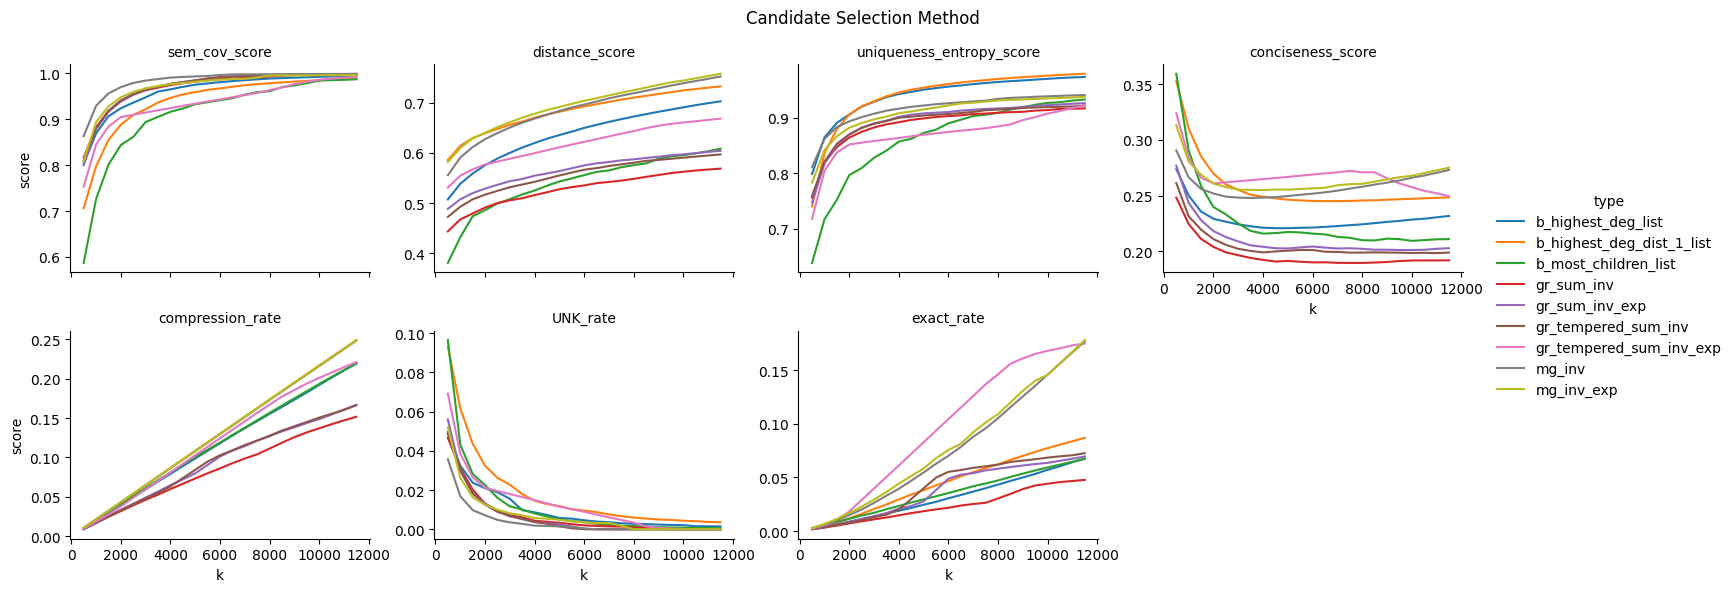

In [45]:
df_performance_elit = pl.read_parquet(f"{configs.Results().path}scores.parquet").filter(pl.col("method") != "b_random_k")
metrics = [
    "sem_cov_score",
    "distance_score",
    "uniqueness_entropy_score",
    "conciseness_score",
    "compression_rate",
    "UNK_rate",
    "exact_rate",
]

df_long = (
    df_performance_elit
    .unpivot(on=metrics, index=["method", "k"], variable_name="variable", value_name="score")
    .rename({"method": "type"})
    .to_pandas()
)

g = sns.relplot(
    data=df_long,
    x="k",
    y="score",
    hue="type",
    col="variable",
    col_wrap=4,
    kind="line",
    # marker="o",
    facet_kws={"sharey": False},
    height=3,
    aspect=1.25,
)
g.set_titles("{col_name}")
g.set_axis_labels("k", "score")

g.fig.suptitle("Candidate Selection Method")
g.tight_layout()

plt.show()


In [46]:
df_performance.sort(by = "sem_cov_score", descending=True)

method,k,sem_cov_score,distance_score,uniqueness_entropy_score,conciseness_score,compression_rate,UNK_rate,exact_rate,num_candidates
str,i64,f64,f64,f64,f64,f64,f64,f64,i64
"""gr_sum_inv_exp""",11500,0.999331,0.604388,0.926159,0.20292,0.166782,0.0,0.069577,7697
"""mg_inv""",11500,0.998937,0.752498,0.940877,0.273096,0.248082,0.0,0.177118,11449
"""mg_inv""",11000,0.998897,0.748021,0.940072,0.270525,0.237291,0.0,0.166631,10951
"""mg_inv""",10500,0.998877,0.743576,0.939339,0.26808,0.226501,0.0,0.156425,10453
"""gr_sum_inv_exp""",11000,0.998829,0.602175,0.925055,0.202419,0.160672,0.0,0.067497,7415
…,…,…,…,…,…,…,…,…,…
"""b_random_k""",2500,0.191916,0.238533,0.31666,0.875564,0.053756,0.540798,0.033196,2480
"""b_random_k""",2000,0.146936,0.18484,0.258114,0.921746,0.04307,0.631227,0.02652,1987
"""b_random_k""",1500,0.119317,0.156677,0.205993,0.947631,0.032362,0.682115,0.019819,1493


# elbow? convex?

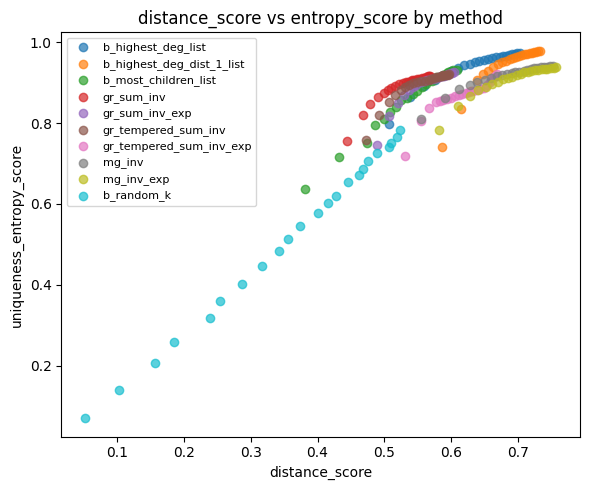

In [47]:
import matplotlib.pyplot as plt

df_plot = df_performance.to_pandas()

methods = df_plot["method"].unique()
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(6, 5))

for i, method in enumerate(methods):
    sub = df_plot[df_plot["method"] == method]
    ax.scatter(sub["distance_score"], sub["uniqueness_entropy_score"],
               color=colors[i % len(colors)], label=method, alpha=0.7)

ax.set_xlabel("distance_score")
ax.set_ylabel("uniqueness_entropy_score")
ax.legend(fontsize=8)
ax.set_title("distance_score vs entropy_score by method")
fig.tight_layout()
plt.show()

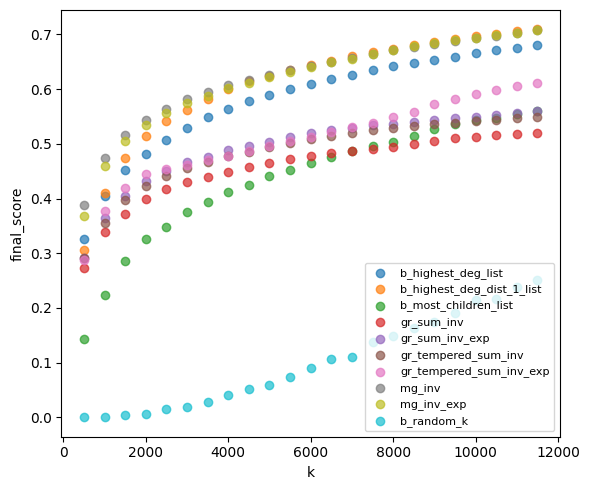

In [48]:
df_performance_new = (df_performance
                      .with_columns(final_score = pl.col("distance_score") * pl.col("uniqueness_entropy_score") * pl.col("sem_cov_score"))
                      .to_pandas())
fig, ax = plt.subplots(figsize=(6, 5))

for i, method in enumerate(methods):
    sub = df_performance_new[df_performance_new["method"] == method]
    ax.scatter(sub["k"], sub["final_score"],
               color=colors[i % len(colors)], label=method, alpha=0.7)

ax.set_xlabel("k")
ax.set_ylabel("final_score")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()